#### Name:- Baibhaw Kumar
#### Assignment - 2


#### Objective:-
In this Assignment, we are asked to train KNN classifier, Random Forest and Decision tree on training set to predict the labels and compare their performance on the test_set
The goal objective will be to use already built in libraries for these task.

#### Importing all the important libraries for this assignment:-

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
%pip install scikit-learn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sklearn

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [25]:
from sklearn.model_selection import train_test_split

#### Step 1:-
Load the MNIST Data, extract the features and labels separately using pre-processing and split them into training and testing ratio.

In [8]:
import os
print(os.getcwd())


C:\Users\kumar\Downloads\Baibhaw_2310110712 (1)


In [9]:
os.chdir("../..")


In [14]:
import os
print(os.getcwd())


C:\Users\kumar\Downloads


In [16]:
import os
print(os.getcwd())


C:\Users\kumar\Downloads


In [30]:
import pandas as pd
import numpy as np

df = pd.read_csv("MNIST_Dataset_1.csv")

print("Any NaN in whole dataset?", df.isna().any().any())
print(df.isna().sum().sum())   # total NaNs


Any NaN in whole dataset? False
0


In [31]:
# Load dataset
data = pd.read_csv("MNIST_Dataset_1.csv")

print("Dataset shape:", data.shape)
data.head()


Dataset shape: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
X = data.iloc[:, 1:].values   # pixel values
y = data.iloc[:, 0].values   # labels

print("Feature shape:", X.shape)
print("Label shape:", y.shape)


Feature shape: (42000, 784)
Label shape: (42000,)


In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,      # 30% test, 70% train
    random_state=42,
    stratify=y
)


In [34]:
class Metrics:
    def accuracy(y_true,y_pred):
        return np.mean(y_true == y_pred)  ## this value gives us the accuracy score

In [37]:
k_values = range(1,5)
accuracies = []
for k in k_values:
    knn_sklearn = KNeighborsClassifier(
        n_neighbors=k,
        metric="euclidean"
    )
    
    knn_sklearn.fit(X_train, y_train)
    
    pred_sklearn = knn_sklearn.predict(X_test)
    acc_sklearn = Metrics.accuracy(y_test, pred_sklearn)
    accuracies.append(acc_sklearn)

best_k = k_values[np.argmax(accuracies)]
print("Best K:", best_k)
print("Best KNN Accuracy:", max(accuracies))


Best K: 1
Best KNN Accuracy: 0.966984126984127


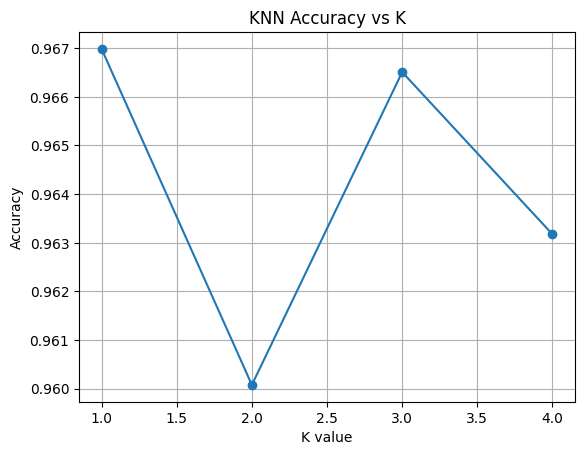

In [41]:
plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K")
plt.grid()
plt.show()


In [38]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
dt_acc = Metrics.accuracy(y_test, y_pred_dt)

print("Decision Tree Accuracy_without_Pruning):", dt_acc)



Decision Tree Accuracy_without_Pruning): 0.844047619047619


In [39]:
dt_pruned = DecisionTreeClassifier(
    max_depth=25,
    min_samples_split=10,
    random_state=42
)

dt_pruned.fit(X_train, y_train)
y_pred_dt_pruned = dt_pruned.predict(X_test)

dt_pruned_acc = Metrics.accuracy(y_test, y_pred_dt_pruned)
print("Decision Tree Accuracy_pruned:", dt_pruned_acc)


Decision Tree Accuracy_pruned: 0.8463492063492063


In [40]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_acc = Metrics.accuracy(y_test, y_pred_rf)
print("Random Forest Accuracy:", rf_acc)


Random Forest Accuracy: 0.9614285714285714


# Performance Analysis of Different Classifiers

## Summary of Results

| Classifier | Key Parameter | Best Accuracy |
| K-Nearest Neighbors (KNN) | k = 1 | 0.96698 |
| Decision Tree (Without Pruning) | No depth limit | 0.84405 |
| Decision Tree (With Pruning) | Limited depth | 0.84635 |
| Random Forest | Ensemble of trees | 0.96143 |


## K-Nearest Neighbors (KNN)

**Best Accuracy:** 0.96698 (k = 1)

The KNN classifier achieved the highest accuracy among all models. When k is set to 1, the classification depends only on the nearest training sample. This works well when the dataset has clear local patterns and strong class separability.

As the value of k increases, predictions become smoother and depend on more neighbors. While this reduces sensitivity to noise, it also increases bias and can lead to underfitting. In this dataset, increasing k resulted in a slight reduction in accuracy.

Overall, the dataset favors local decision making, which explains the strong performance of KNN with k equal to 1.


## Decision Tree Without Pruning

**Accuracy:** 0.84405

The unpruned decision tree grows until all training samples are perfectly classified. This creates a very complex model that captures noise present in the training data.

As a result, the model performs poorly on unseen data. Although training accuracy may be high, test accuracy remains low due to overfitting.

This shows that unrestricted tree growth reduces generalization ability.


## Decision Tree With Pruning

**Accuracy:** 0.84635

Pruning limits the depth of the decision tree and removes unnecessary branches. This slightly improves test accuracy compared to the unpruned version.

However, increasing the depth of the pruned tree beyond an optimal point leads to a decrease in accuracy. This happens because the model again starts learning noise rather than meaningful patterns.

Pruning helps control model complexity, but careful tuning of depth is required.


## Random Forest

**Accuracy:** 0.96143

Random Forest significantly improves performance over a single decision tree. It combines multiple trees trained on different subsets of data and features.

This approach reduces variance and improves robustness. The model generalizes well and produces stable predictions.

Although Random Forest performs very well, it slightly underperforms KNN in this case. This suggests that local similarity based classification is more suitable for this dataset.


## Conclusion

KNN with k equal to 1 provides the best performance due to strong local patterns in the dataset. Decision trees tend to overfit unless pruning is applied. Pruned trees generalize better but require careful depth selection. Random Forest achieves high accuracy by combining multiple trees and reducing variance. Overall, proper model and parameter selection plays a crucial role in achieving good classification performance.
